<a href="https://colab.research.google.com/github/leeobazzana01/data-science-and-big-data/blob/main/know_your_costumer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final - Online Shoppers Purchasing Intention Dataset

Esse trabalho corresponde à entrega do Projeto Final da disciplina de Data Science e Big Data, lecionada pelo Prof. Dr. Márcio Leandro Gonçalves.

**Autores: Leonardo José Bazana Lima e Pedro Paulo Fonteles Tooda.**

## Pipeline

O projeto consiste de um pipeline completo de Pré Processamento, Data Handling, Normalização dos Dados, PCA para clustering com o Algoritmo K-Means, visualização dos clusters PCA, modelagem supervisionada com Random Forest e por último a Regressão Logística.

0. Imports
1. Carregamento dos dados
2. EDA inicial
3. Pré processamento: encoding
4. Train/test split ESTRATIFICADO
5. Padronização (fit no treino, transform no teste)
6. Exploração não supervisionada: PCA diagnóstico + K-Means + silhouette
7. Visualização PCA 2D dos clusters
8. Comparação dos modelos e  estudo completo de perfil do cliente
9. Cluster como feature: melhora ou não a previsão?
10. Conclusões

## Objetivos Finais
Gerar insights profundos sobre o comportamento dos usuários deste dataset, estruturando uma estratégia robusta de Know Your Customer (KYC). Com isso, buscaremos prever com precisão quais clientes têm maior propensão de compra, viabilizando a adoção de estratégias de marketing direcionadas para maximizar as taxas de conversão.

## Metodologia e Recursos

Buscamos explorar a Plataforma Google Colab em conjunto com os Datasets da **Kaggle**. A bibliografia utilizada para desenvolvimento une o conteúdo proposto da disciplina (sobretudo os códigos oferecidos como exemplo na implementação de cada Modelo de Machine Learning) bem como o livro "Hands on Machine Learning", que serviu de referência para o entendimento e adaptação dos Algoritmos visando solucionar o problema proposto e as hipóteses validadas. Além disso, ao longo do desenvolvimento, recorremos ao uso de Inteligência Artificial (Google Gemini, integrado ao Colab) como ferramenta para auxiliar na correção de diversos bugs de código.


### Etapa 0: imports das dependências

In [ ]:
#project dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler #para normalização
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#variáveis de ambiente c/ chave da kaggle
from google.colab import userdata

### Etapa 1: carregamento dos dados

In [ ]:
#variáveis 'globais'
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#método para obter a chave de API (kaggle) do ambiente
userdata.get('KAGLE_API_TOKEN')

#baixando o dataset em ambiente de execução
!kaggle datasets download -d imakash3011/online-shoppers-purchasing-intention-dataset

#desempacotando os dados
with zipfile.ZipFile('online-shoppers-purchasing-intention-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./') #extraindo para o path local

print("Dataset pronto para uso!")

Dataset URL: https://www.kaggle.com/datasets/imakash3011/online-shoppers-purchasing-intention-dataset
License(s): other
online-shoppers-purchasing-intention-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset pronto para uso!


In [ ]:
#lendo o dataset e criando duas variáveis diferentes, a original (dataset) e a variável em que iremos trabalhar (new_dataset)
dataset = pd.read_csv('online_shoppers_intention.csv')

#validando a leitura
print("Dataset HEADER: \n")
dataset.info()

Dataset HEADER: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Traf

### Etapa 2: Análise Exploratória dos Dados (EDA)

---



In [ ]:
#verificando a distribuição de compras
print("\nDistribuição do target Revenue:")
print(dataset["Revenue"].value_counts(normalize=True).round(4))

#validando ausência de valores
print("\nValores ausentes por coluna no dataset original:")
print(dataset.isna().sum().sum(), "valores ausentes no total")


Distribuição do target Revenue:
Revenue
False    0.8453
True     0.1547
Name: proportion, dtype: float64

Valores ausentes por coluna no dataset original:
0 valores ausentes no total


Podemos notar que o Dataset está Desbalanceado, pois a análise da variável "Revenue" (que descreve se a compra foi ou não realizada por aquele cliente) apresenta 84,53% de compras não convertidas. Apenas 15,47% dos usuários realizou a compra de fato.

In [ ]:
print("\nInformações Gerais de cada variável: \n")
dataset.info()


Informações Gerais de cada variável: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-n

In [ ]:
#loop percorre a lista de colunas validando o total de categorias existentes em cada uma
for coluna in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
    print(f"{coluna}: {dataset[coluna].nunique()} categorias únicas")

OperatingSystems: 8 categorias únicas
Browser: 13 categorias únicas
Region: 9 categorias únicas
TrafficType: 20 categorias únicas


### Etapa 3: Pré Processamento dos dados

In [ ]:
#criando e trabalhando na cópia
novo_dataset = dataset.copy()

#convertendo as variáveis booleanas 'weekend' e 'revenue' para inteiras
novo_dataset["Weekend"] = novo_dataset["Weekend"].astype(int)
novo_dataset["Revenue"] = novo_dataset["Revenue"].astype(int)

novo_dataset.info() #para validação

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
#transformando os meses do ano em um dicionário pra tratar como período cíclico
dicionario_meses = {
    "Feb": 2, "Mar": 3, "May": 5, "June": 6, "Jul": 7,
    "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12,
}

novo_dataset["Mes_numero"] = novo_dataset["Month"].map(dicionario_meses)

#aplicaremos as funções de seno e cosseno da lib numpy
novo_dataset["Mes_sin"] = np.sin(2 * np.pi * novo_dataset["Mes_numero"] / 12) #cada mês representará um "ângulo" no círculo
novo_dataset["Mes_cos"] = np.cos(2 * np.pi * novo_dataset["Mes_numero"] / 12)

novo_dataset = novo_dataset.drop(columns=["Month", "Mes_numero"])

Explicação aprofundada do procedimento realizado acima:

A maioria dos Algoritmos trabalha com o cálculo de distância euclidiana. Dessa forma, ao converter as variáveis categóricas dos Meses para variáveis numéricas, caso aplicássemos isso diretamente em um modelo de ML convencional, ele iria realizar a seguinte interpretação: existe uma distância de 11 meses entre janeiro e dezembro quando, na realidade, a distância entre eles é de apenas 1 mês.   

A solução é "dobrar" a linha reta de 1 a 12 em um círculo trigonométrico aplicando as funções seno e cosseno.

In [ ]:
#aplicando o one hot encoder no tipo de visitante
novo_dataset = pd.get_dummies(novo_dataset, columns=["VisitorType"], prefix="Visitor", dtype=int)

#one hot encoding para a lista de variáveis categóricas
colunas = ["OperatingSystems", "Browser", "Region", "TrafficType"]
novo_dataset = pd.get_dummies(novo_dataset, columns=colunas, prefix=colunas, dtype=int)

print(f"Shape após encoding: {novo_dataset.shape}")

Shape após encoding: (12330, 67)


In [ ]:
#separando as features e a variável target (revenue)
y = novo_dataset["Revenue"]
x = novo_dataset.drop(columns=["Revenue"])

#validando
print(f"Shape de x: {x.shape}")
print(f"Shape de y: {y.shape}")


Shape de x: (12330, 66)
Shape de y: (12330,)


### Etapa 4: Train test split estratificado


In [ ]:
#essa estragégia visa mitigar o que conhecemos como 'data_leakage', ou vazamento de dados
#sem essa etapa, as estatísticas aprendidas em teste poderiam contaminar a avaliação
x_treino, x_test, y_treino, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

#validando
print(f"Treino: {x_treino.shape} | Teste: {x_test.shape}")
print(f"Conversão no treino: {y_treino.mean():.3%} | no teste: {y_test.mean():.3%}")

Treino: (9864, 66) | Teste: (2466, 66)
Conversão no treino: 15.470% | no teste: 15.491%


### Etapa 5: padronização

Os métodos de análise de dados comprovaram a diferença de amplitude entre as variáveis contínuas. Ou seja, enquanto o range de algumas vai de 0 a 1 (por exemplo), temos colunas como "Administrative Duration" cujo range a muito maior. Portanto, é extremamente importante buscar a padronização das variáveis contínuas.

Seguiremos as seguintes "regras" para normalização:

(1) Aplicaremos **log(x+1)** nas features de cauda longa (o deslocamento horizontal da função evita que qualquer valor resulte em zero)

(2) Padronizaremos apenas as variáveis contínuas

(3) Faremos fit no treino e transform no teste

In [ ]:
#lista de features destorcidas
features_distorcidas = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "PageValues",
    "Administrative",
    "Informational",
    "ProductRelated",
]

#lista de features contínuas
features_continuas = features_distorcidas + ["BounceRates", "ExitRates", "SpecialDay"]

In [ ]:
#aplicando log1p
x_treino_proc = x_treino.copy()
x_test_proc = x_test.copy()

for col in features_distorcidas:
    x_treino_proc[col] = np.log1p(x_treino_proc[col])
    x_test_proc[col] = np.log1p(x_test_proc[col])

In [ ]:
#aplicando standarscaler APENAS EM VARIÁVEIS CONTÍNUAS
scaler = StandardScaler() #inicaliza o objeto scaler herdando os atributos e parâmetros da lib

x_treino_proc[features_continuas] = scaler.fit_transform(x_treino_proc[features_continuas])
x_test_proc[features_continuas] = scaler.transform(x_test_proc[features_continuas])

#validando
print("Estatísticas das contínuas após padronização (treino):")
print(x_treino_proc[features_continuas].describe().loc[["mean", "std"]].round(3))

Estatísticas das contínuas após padronização (treino):
      Administrative_Duration  Informational_Duration  \
mean                     -0.0                    -0.0   
std                       1.0                     1.0   

      ProductRelated_Duration  PageValues  Administrative  Informational  \
mean                     -0.0        -0.0            -0.0            0.0   
std                       1.0         1.0             1.0            1.0   

      ProductRelated  BounceRates  ExitRates  SpecialDay  
mean             0.0          0.0        0.0        -0.0  
std              1.0          1.0        1.0         1.0  


### Etapa 6 não supervisionada: PCA diagnóstico + k means

O objetivo principal é responder à hipótese: existem clusters de clientes?

É importante desconsiderar a coluna "PageValues" no clustering, uma vez que é calculada

In [ ]:
leakage_column = ["PageValues"]

x_cluster = x_treino_proc.drop(columns=leakage_column)

#validando
print(f"Features usadas no Clustering: {x_cluster.shape[1]}")

Features usadas no Clustering: 65


In [ ]:
#PCA de diagnóstico (com todas as componentes) pra analisar a variância
pca_total = PCA(random_state=RANDOM_STATE)

#fit
pca_total.fit(x_cluster)

#proporção de variância
prop_var = pca_total.explained_variance_ratio_
acumulo_var = np.cumsum(prop_var)

n_85 = int(np.argmax(acumulo_var >= 0.85)) + 1
n_95 = int(np.argmax(acumulo_var >= 0.95)) + 1

print(f"PC1: {prop_var[0]*100:.2f}% | PC2: {prop_var[1]*100:.2f}% "
      f"| PC1+PC2: {(prop_var[0]+prop_var[1])*100:.2f}%")

print(f"PCs para 85% da variância: {n_85} | para 95%: {n_95}")

PC1: 32.72% | PC2: 13.13% | PC1+PC2: 45.85%
PCs para 85% da variância: 12 | para 95%: 23


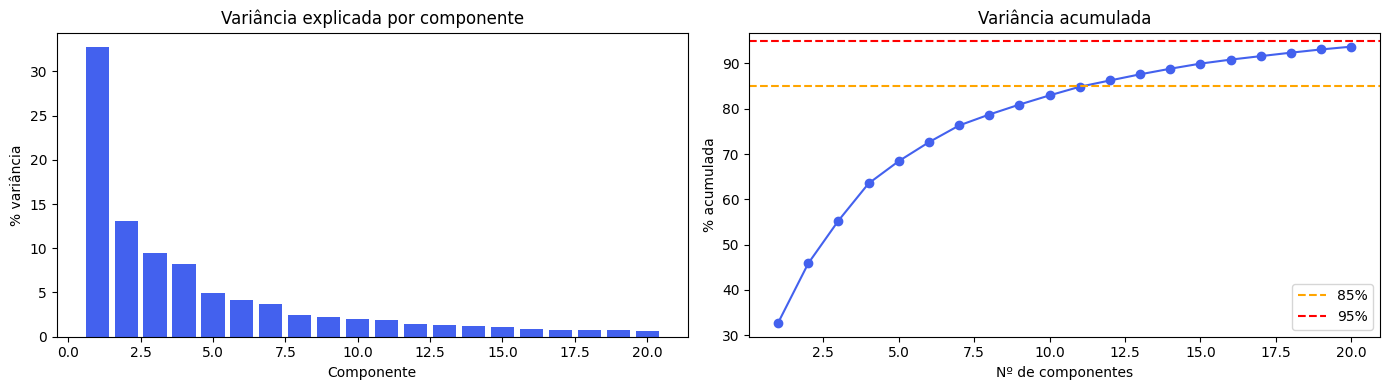

In [ ]:
#scree plot (gráfico de sedimentação) p análise de comportamento da variância

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
n_show = min(20, len(prop_var))
ax1.bar(range(1, n_show + 1), prop_var[:n_show] * 100, color="#4361EE")
ax1.set_title("Variância explicada por componente")
ax1.set_xlabel("Componente"); ax1.set_ylabel("% variância")
ax2.plot(range(1, n_show + 1), acumulo_var[:n_show] * 100, marker="o", color="#4361EE")
ax2.axhline(85, color="orange", ls="--", label="85%")
ax2.axhline(95, color="red", ls="--", label="95%")
ax2.set_title("Variância acumulada")
ax2.set_xlabel("Nº de componentes"); ax2.set_ylabel("% acumulada")
ax2.legend()
plt.tight_layout()
plt.savefig("plotando_graf_segmentacao.png", dpi=140, bbox_inches="tight")
plt.show()

### Etapa 6 - K means

O Algoritmo K means irá rodar no conjunto de dados 'original' (x_cluster) e não no PCA reduzido. O PCA, na etapa acima, é útil apenas para diagnóstico e visualização

In [ ]:
#intervalo de testes pra identificação do 'cotovelo'
#matematicamente, o cotovelo corresponde o ponto onde há menor diferença entre a derivada dos pontos
#ou seja, é onde há maior diferença entre o coeficiente da reta de inclinação entre dois valores consecutivos de x

K_RANGE = range(2,11)
inercia, score_silhueta = [], []

#sub amostra p acelerar o silhouette
amostra_idx = x_cluster.sample(n=3000, random_state=RANDOM_STATE).index

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=15,
                random_state=RANDOM_STATE, max_iter=300) #parâmetros do k means

    labels_k = km.fit_predict(x_cluster)
    inercia.append(km.inertia_)

    sil = silhouette_score(x_cluster.loc[amostra_idx], labels_k[x_cluster.index.get_indexer(amostra_idx)])
    score_silhueta.append(sil)

    print(f"K={k:2d} | Inércia={km.inertia_:,.0f} | Silhouetta={sil:.4f}")

K= 2 | Inércia=103,963 | Silhouetta=0.1822
K= 3 | Inércia=85,049 | Silhouetta=0.2561
K= 4 | Inércia=72,876 | Silhouetta=0.1986
K= 5 | Inércia=65,475 | Silhouetta=0.2123
K= 6 | Inércia=62,415 | Silhouetta=0.1710
K= 7 | Inércia=60,263 | Silhouetta=0.1471
K= 8 | Inércia=58,187 | Silhouetta=0.1420
K= 9 | Inércia=56,520 | Silhouetta=0.1334
K=10 | Inércia=55,073 | Silhouetta=0.1329


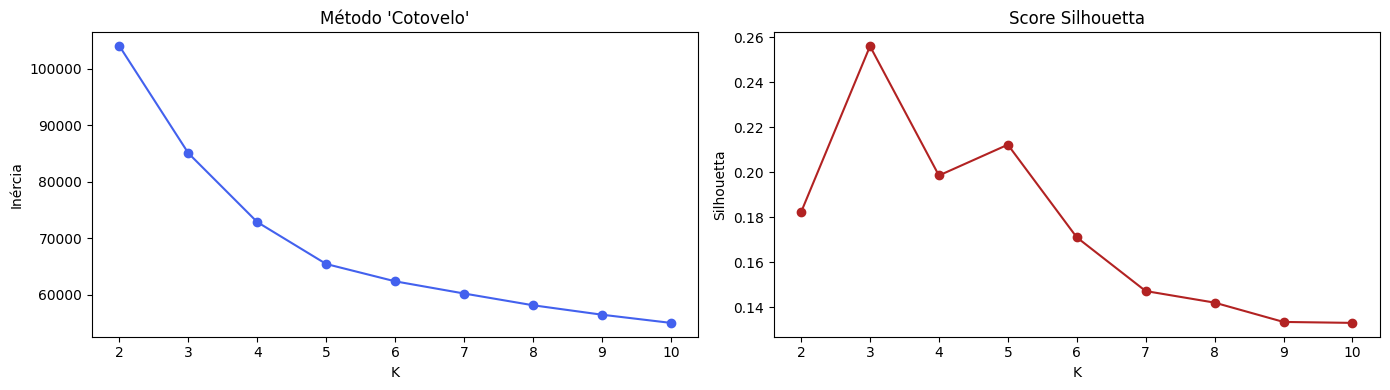

In [ ]:
#plotando o gráfico com cotovelo e silhueta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(list(K_RANGE), inercia, marker="o", color="#4361EE")
ax1.set_title("Método 'Cotovelo'"); ax1.set_xlabel("K"); ax1.set_ylabel("Inércia")
ax2.plot(list(K_RANGE), score_silhueta, marker="o", color="#B22222")
ax2.set_title("Score Silhouetta"); ax2.set_xlabel("K"); ax2.set_ylabel("Silhouetta")
plt.tight_layout()
plt.savefig("plotando_diagnostico_kmeans.png", dpi=140, bbox_inches="tight")
plt.show()

In [ ]:
#apresentando os resultados e interpretação

k_ideal = list(K_RANGE)[int(np.argmax(score_silhueta))]
sil_ideal = max(score_silhueta)

print(f"\nMelhor K pelo silhouetta: {k_ideal} (silhouette={sil_ideal:.4f})")
print(
    "INTERPRETAÇÃO: silhouette de 0.2561 está na faixa de 'estrutura fraca' \n"
    "(0.25-0.50) do ponto de vista GEOMÉTRICO, os clusters não são bolhas \n"
    "bem separadas no espaço de 65 dimensões. Isso é esperado, dado que a \n"
    "variância está distribuída entre muitas componentes (12 PCs para 85%). \n"
    "\n"
    "PORÉM, isso NÃO significa que os clusters são inúteis. A qualidade real \n"
    "só se revela na análise comportamental da Etapa 9: clusters podem ser \n"
    "geometricamente sobrepostos mas comportamentalmente distintos, o que é o \n"
    "que importa para segmentação de marketing. Seguimos com K=3."
)


Melhor K pelo silhouetta: 3 (silhouette=0.2561)
INTERPRETAÇÃO: silhouette de 0.2561 está na faixa de 'estrutura fraca' 
(0.25-0.50) do ponto de vista GEOMÉTRICO, os clusters não são bolhas 
bem separadas no espaço de 65 dimensões. Isso é esperado, dado que a 
variância está distribuída entre muitas componentes (12 PCs para 85%). 

PORÉM, isso NÃO significa que os clusters são inúteis. A qualidade real 
só se revela na análise comportamental da Etapa 9: clusters podem ser 
geometricamente sobrepostos mas comportamentalmente distintos, o que é o 
que importa para segmentação de marketing. Seguimos com K=3.


### Etapa 7 - Visualização dos Clusters PCA


In [ ]:
#parâmetros do k final
k_final = KMeans(n_clusters=k_ideal, init="k-means++", n_init=15,
                 random_state=RANDOM_STATE)

labels_final = k_final.fit_predict(x_cluster) #fitting

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE) #parâmetros do pca 2d
x_pca2 = pca_2d.fit_transform(x_cluster)
centroids_pca = pca_2d.transform(k_final.cluster_centers_) #ambos em x_cluster

var1, var2 = pca_2d.explained_variance_ratio_*100 #percentual de variancia p pca2d

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


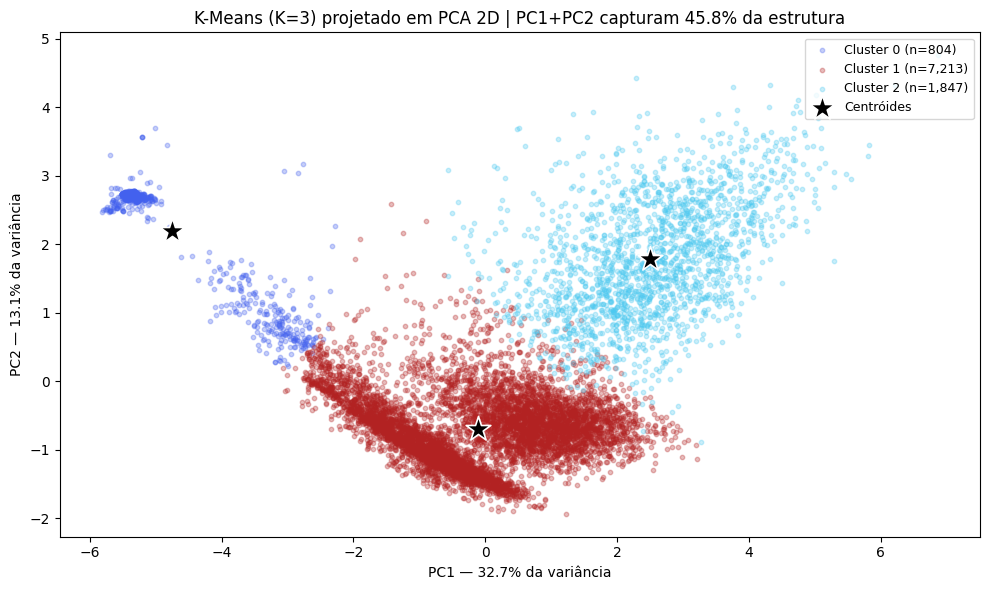

In [ ]:
#apresentando resultados
fig, ax = plt.subplots(figsize=(10, 6))

palette = ["#4361EE", "#B22222", "#4CC9F0", "#F4A261", "#2EC4B6"]

for c in range(k_ideal):
    mascara = labels_final == c
    ax.scatter(x_pca2[mascara, 0], x_pca2[mascara, 1],
               s=10, alpha=0.3, color=palette[c % len(palette)],
               label=f"Cluster {c} (n={mascara.sum():,})")
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker="*", s=350, c="black", edgecolors="white", linewidths=1.2,
           zorder=10, label="Centróides")

ax.set_xlabel(f"PC1 — {var1:.1f}% da variância")
ax.set_ylabel(f"PC2 — {var2:.1f}% da variância")
ax.set_title(
    f"K-Means (K={k_ideal}) projetado em PCA 2D | "
    f"PC1+PC2 capturam {var1+var2:.1f}% da estrutura"
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("plotando_pca_clusters_2d.png", dpi=140, bbox_inches="tight")
plt.show()


### Etapa 8: Modelagem Supervisionada com Random Forest

O foco será em utilizar o Random Forest para identificar padrões e resolver o problema real: a previsão de Revenue (conversão).

A abordagem será em treinar duas versões diferentes do Random forest, uma delas será 'alimentada' com os dados de PagesValues para que possamos diagnosticar o vazamento.

In [ ]:
def avalia_modelo(model, x_treino, y_treino, x_test, y_test, name):
    #treinando, avaliando e retornando métricas

    model.fit(x_treino, y_treino)

    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    metricas = {
        "model": name,
        "auc": roc_auc_score(y_test, y_proba),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
    }
    print(f"\n {name} ")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {metricas['auc']:.4f}")
    print("Matriz de confusão:")
    print(confusion_matrix(y_test, y_pred))
    return metricas, y_proba, y_pred

#random forest c TODAS as features (incluindo PageValues)
rf_completo = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
m_rf_completo, proba_rf_full, _ = avalia_modelo(
    rf_completo, x_treino_proc, y_treino, x_test_proc, y_test, "Random Forest (com PageValues)"
)


 Random Forest (com PageValues) 
              precision    recall  f1-score   support

           0      0.952     0.901     0.926      2084
           1      0.583     0.754     0.658       382

    accuracy                          0.878      2466
   macro avg      0.768     0.828     0.792      2466
weighted avg      0.895     0.878     0.884      2466

ROC-AUC: 0.9248
Matriz de confusão:
[[1878  206]
 [  94  288]]


In [ ]:
#random forest sem page values,,,,,,,,
rf_limpo = RandomForestClassifier(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=10,        #ANTES: 5 → mais conservador
    max_features="sqrt",        # default, mas explícito para documentar
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

#avaliação do modelo
m_rf_limpo, proba_rf_limpo, pred_rf_limpo = avalia_modelo(
    rf_limpo,
    x_treino_proc.drop(columns=["PageValues"]), y_treino,
    x_test_proc.drop(columns=["PageValues"]), y_test,
    "Random Forest (sem PageValues)"
)


 Random Forest (sem PageValues) 
              precision    recall  f1-score   support

           0      0.910     0.754     0.825      2084
           1      0.307     0.594     0.405       382

    accuracy                          0.729      2466
   macro avg      0.608     0.674     0.615      2466
weighted avg      0.817     0.729     0.760      2466

ROC-AUC: 0.7661
Matriz de confusão:
[[1571  513]
 [ 155  227]]


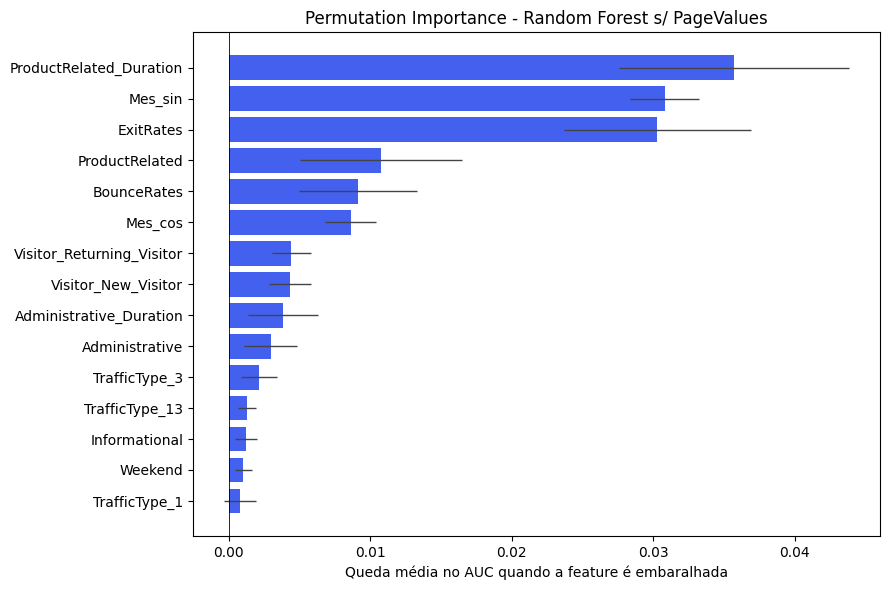


Top 10 features preditivas (excluindo PageValues):
ProductRelated_Duration      0.0357
Mes_sin                      0.0308
ExitRates                    0.0303
ProductRelated               0.0108
BounceRates                  0.0091
Mes_cos                      0.0086
Visitor_Returning_Visitor    0.0044
Visitor_New_Visitor          0.0044
Administrative_Duration      0.0038
Administrative               0.0030
dtype: float64


In [ ]:
#feature importance e recursos gráficos da versão SEM PAGE VALUES
x_test_sem_pv = x_test_proc.drop(columns=["PageValues"])
perm = permutation_importance(
    rf_limpo, x_test_sem_pv, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    n_jobs=-1, scoring="roc_auc"
)

perm_imp = pd.Series(perm.importances_mean, index=x_test_sem_pv.columns)
perm_std = pd.Series(perm.importances_std, index=x_test_sem_pv.columns)
top15 = perm_imp.sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(top15)), perm_imp.loc[top15][::-1],
        xerr=perm_std.loc[top15][::-1],
        color="#4361EE", error_kw=dict(ecolor="#444", lw=1))
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15[::-1])
ax.set_xlabel("Queda média no AUC quando a feature é embaralhada")
ax.set_title("Permutation Importance - Random Forest s/ PageValues")
ax.axvline(0, color="black", lw=0.6)
plt.tight_layout()
plt.savefig("plot_permutation_importance.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nTop 10 features preditivas (excluindo PageValues):")
print(perm_imp.sort_values(ascending=False).head(10).round(4))


## Etapa 9: PERFIL DE CLIENTE POR CLUESTES

A presente etapa propõe se a indicar um perfil e responder "quem são os clientes desse dataset".

Anexamos o 'cluster_id' aos DADOS ORIGINAIS (não padrozinados) e o target para interpretar médias em unidades reais (minutos, contagens, taxas)

In [ ]:
#recupera os dados originais do conjunto de treino (que clusterizamos)
x_treino_orig = dataset.loc[x_treino.index].copy() #copia na variável x_treino_orig
x_treino_orig["cluster"] = labels_final
x_treino_orig["convertido"] = y_treino.values


In [ ]:
#taxa de conversão por cluster

print("TAXA DE CONVERSÃO POR CLUSTER")
print("=" * 50)

conversao_cluster = x_treino_orig.groupby("cluster").agg(
    n_sessoes=("convertido", "count"),
    n_conversoes=("convertido", "sum"),
    taxa_conversao=("convertido", "mean")
).round(4)

conversao_cluster["lift_vs_baseline"] = (
    conversao_cluster["taxa_conversao"] / y_treino.mean()
).round(2)
print(conversao_cluster)

TAXA DE CONVERSÃO POR CLUSTER
         n_sessoes  n_conversoes  taxa_conversao  lift_vs_baseline
cluster                                                           
0              804             3          0.0037              0.02
1             7213          1078          0.1495              0.97
2             1847           445          0.2409              1.56


In [ ]:
#descrevendo o perfil comportamental por cluster
print("\nPERFIL COMPORTAMENTAL MÉDIO POR CLUSTER (valores originais)")
print("=" * 50)

features_comportamento = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
]
perfil = x_treino_orig.groupby("cluster")[features_comportamento].mean().round(2)
print(perfil.T)  #transposto p facilitar leitura



PERFIL COMPORTAMENTAL MÉDIO POR CLUSTER (valores originais)
cluster                      0       1        2
Administrative            0.03    1.85     5.15
Administrative_Duration   0.21   63.25   186.78
Informational             0.02    0.04     2.53
Informational_Duration    0.09    0.26   183.69
ProductRelated            2.27   26.12    64.97
ProductRelated_Duration  34.10  957.04  2584.50
BounceRates               0.17    0.01     0.01
ExitRates                 0.18    0.03     0.02
PageValues                0.00    5.98     8.39
SpecialDay                0.10    0.07     0.03


In [ ]:
#perfil categórico: padrões de comportamento por dominancia de mes, tipo de visitante, weekend, as variáveis categóricas do projeto
print("\nPERFIL CATEGÓRICO POR CLUSTER")
print("=" * 50)

def dominante(serie):
    #retorna a caregocia mais frequente
    vc = serie.value_counts(normalize=True)
    return f"{vc.index[0]} ({vc.iloc[0]*100:.1f}%)"

#categorias e perfis
perfil_cat = x_treino_orig.groupby("cluster").agg(
    visitante_dominante=("VisitorType", dominante),
    mes_dominante=("Month", dominante),
    weekend_dominante=("Weekend", dominante),
    trafego_dominante=("TrafficType", dominante),
)
#apresentando os resultados
print(perfil_cat)



PERFIL CATEGÓRICO POR CLUSTER
               visitante_dominante mes_dominante weekend_dominante  \
cluster                                                              
0        Returning_Visitor (95.0%)   May (34.6%)     False (82.7%)   
1        Returning_Visitor (83.7%)   May (27.5%)     False (77.0%)   
2        Returning_Visitor (89.1%)   Nov (29.6%)     False (73.4%)   

        trafego_dominante  
cluster                    
0               1 (30.6%)  
1               2 (31.3%)  
2               2 (44.0%)  


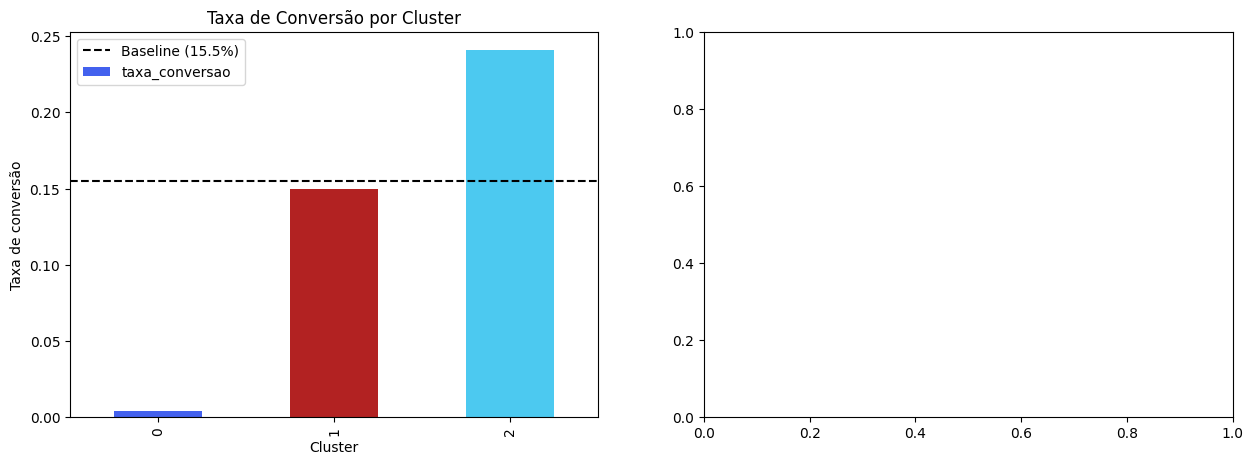

In [ ]:
#visualização: gráfico de barras da taxa de converção
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#taxa de conversão
conversao_cluster["taxa_conversao"].plot(
    kind="bar", ax=axes[0], color=["#4361EE", "#B22222", "#4CC9F0"]

)

axes[0].axhline(y_treino.mean(), color="black", ls="--",
                label=f"Baseline ({y_treino.mean()*100:.1f}%)")

axes[0].set_title("Taxa de Conversão por Cluster")

axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Taxa de conversão")

axes[0].legend()

In [ ]:

#heatmap comportamental comportamental (z-score entre clusters para comparação visual)
perfil_z = perfil.T

perfil_z_norm = perfil_z.sub(perfil_z.mean(axis=1), axis=0).div(
    perfil_z.std(axis=1).replace(0, 1), axis=0
)

sns.heatmap(perfil_z_norm, annot=perfil.T, fmt=".1f",
            cmap="RdBu_r", center=0, ax=axes[1],
            cbar_kws={"label": "z-score entre clusters"})

axes[1].set_title("Perfil Comportamental por Cluster\n(cor = z-score, número = valor médio real)")
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("plot_perfil_clusters.png", dpi=140, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:
#nomeando cluster (interpretação do negócio)
#com base nas celulas anteriores, atribuimos nomes descritivos aos clusters
nomes_clusters = {
    0: "Rejeitores de Passagem",     #8% dos users, 0.37% conversão, lift 0.02x
    1: "Navegadores Regulares",       #73.1% dos usuários, 14.95% conversão, lift 0.97x
    2: "Alta Intenção Sazonal",       #18.7% dos usuários, 24.09% conversão, lift 1.56x
}

print("\nPERFIL DE CADA CLUSTER (nomes definidos com base nos dados):")
print("=" * 50)
print("Cluster 0 | Rejeitores de Passagem")
print("-> 804 sessões, 3 conversões (0.37%). Lift 0.02x: praticamente não converte.")
print("-> Sessão de 30 segundos, 2 produtos vistos, BounceRate 17%, ExitRate 18%.")
print("-> 95% são visitantes retornantes com PageValues zero, PERFIL TÍPICO:")
print("bots, funcionários internos, ou usuários com hábito de checagem.")
print()
print("Cluster 1 | Navegadores Regulares")
print("-> 7.213 sessões, 1.078 conversões (14.95%). Lift 0.97x — o baseline.")
print("-> Sessão de 16 min, 26 produtos vistos, BounceRate 1%, ExitRate 3%.")
print("-> É a massa do e-commerce: 73% do tráfego. 83% de retornantes.")
print()
print("Cluster 2 | Alta Intenção Sazonal")
print("-> 1.847 sessões, 445 conversões (24.09%). Lift 1.56x: o segmento premium.")
print("-> Sessão de 43 min, 65 produtos vistos, 5 páginas administrativas.")
print("-> 29.6% das sessões em Novembro (Black Friday). TrafficType 2 domina (44%).")


PERFIL DE CADA CLUSTER (nomes definidos com base nos dados):
Cluster 0 | Rejeitores de Passagem
-> 804 sessões, 3 conversões (0.37%). Lift 0.02x: praticamente não converte.
-> Sessão de 30 segundos, 2 produtos vistos, BounceRate 17%, ExitRate 18%.
-> 95% são visitantes retornantes com PageValues zero, PERFIL TÍPICO:
bots, funcionários internos, ou usuários com hábito de checagem.

Cluster 1 | Navegadores Regulares
-> 7.213 sessões, 1.078 conversões (14.95%). Lift 0.97x — o baseline.
-> Sessão de 16 min, 26 produtos vistos, BounceRate 1%, ExitRate 3%.
-> É a massa do e-commerce: 73% do tráfego. 83% de retornantes.

Cluster 2 | Alta Intenção Sazonal
-> 1.847 sessões, 445 conversões (24.09%). Lift 1.56x: o segmento premium.
-> Sessão de 43 min, 65 produtos vistos, 5 páginas administrativas.
-> 29.6% das sessões em Novembro (Black Friday). TrafficType 2 domina (44%).


## Etapa 10: Teste de Hipótese

Validamos a seguinte hipótese: o Cluster como feature melhora a previsão do Random Forest nesse Dataset?

RF deveria melhorar o AUC. Se não melhorar, confirma que a segmentação É DESCRITIVA (útil para marketing) mas não PREDITIVA (não vai ajudar a prever conversão além do que já temos).

In [ ]:
#aplica o msm k means aos dados de teste

x_test_cluster = x_test_proc.drop(columns=["PageValues"])
cluster_test = k_final.predict(x_test_cluster)

In [ ]:
#anexa como one hot (n como inteiro, evita ordinalidade falsa)

def anexar_cluster_onehot(df, labels, k):
    for c in range(k):
        df[f"cluster_{c}"] = (labels == c).astype(int)
    return df

x_treino_aug = anexar_cluster_onehot(
    x_treino_proc.drop(columns=["PageValues"]).copy(),
    labels_final, k_ideal
)
x_test_aug = anexar_cluster_onehot(
    x_test_proc.drop(columns=["PageValues"]).copy(),
    cluster_test, k_ideal
)


In [ ]:
#random forest
rf_com_cluster = RandomForestClassifier(
    n_estimators=200, max_depth=16, min_samples_leaf=10,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
m_rf_cluster, _, _ = avalia_modelo(
    rf_com_cluster, x_treino_aug, y_treino, x_test_aug, y_test,
    "Random Forest (s/ PageValues + cluster como feature)"
)



 Random Forest (s/ PageValues + cluster como feature) 
              precision    recall  f1-score   support

           0      0.911     0.748     0.821      2084
           1      0.304     0.599     0.403       382

    accuracy                          0.725      2466
   macro avg      0.607     0.674     0.612      2466
weighted avg      0.817     0.725     0.757      2466

ROC-AUC: 0.7663
Matriz de confusão:
[[1559  525]
 [ 153  229]]


In [ ]:
#comparação lado a lado

delta_auc = m_rf_cluster["auc"] - m_rf_limpo["auc"]

print(f"\nAUC sem cluster: {m_rf_limpo['auc']:.4f}")
print(f"AUC com cluster: {m_rf_cluster['auc']:.4f}")
print(f"Delta:           {delta_auc:+.4f}")

if abs(delta_auc) < 0.005:
    print("Diferença desprezível. Confirma que os clusters são DESCRITIVOS, não preditivos")
    print("Uso indicado para segmentar campanhas, não para melhorar o modelo.")
elif delta_auc > 0:
    print("Ganho pequeno mas real. Cluster tem informação marginal útil.")
else:
    print("Piorou. O cluster está introduzindo ruído. Não usar.")


AUC sem cluster: 0.7661
AUC com cluster: 0.7663
Delta:           +0.0002
Diferença desprezível. Confirma que os clusters são DESCRITIVOS, não preditivos
Uso indicado para segmentar campanhas, não para melhorar o modelo.


# Etapa 11 — Conclusões Finais

## Contexto do estudo

Analisamos o **Online Shoppers Purchasing Intention Dataset** (12.330 sessões de e-commerce, 15.47% de conversão) com o objetivo de estruturar uma estratégia de **Know Your Customer (KYC)**. O pipeline seguiu quatro frentes complementares: (1) tentativa de segmentação não supervisionada via K-Means, (2) caracterização detalhada dos perfis emergentes, (3) modelagem preditiva via Random Forest, e (4) validação da utilidade dos clusters como feature preditiva.

## 1. Existem clusters de clientes? A resposta é sim, mas não do jeito esperado

O silhouette score obtido (0.2561 em K=3) fica na faixa de "estrutura fraca" do ponto de vista **geométrico**. Foram necessárias 12 componentes principais para explicar 85% da variância, confirmando que os visitantes não formam bolhas isoladas no espaço de features.

**Porém, a análise comportamental por cluster revelou o oposto do que o silhouette sugeria:** os três grupos identificados apresentam diferenças brutais nas métricas que importam para o negócio. A taxa de conversão varia **65 vezes** entre o menor e o maior cluster (0.37% no Cluster 0 vs 24.09% no Cluster 2).

**Conclusão metodológica:** silhouette mede separação geométrica, não relevância de negócio. Neste dataset, os clusters são geometricamente sobrepostos mas comportamentalmente distintos — que é exatamente o que precisamos para segmentação de marketing.

## 2. Os três perfis identificados

### Cluster 0 — "Rejeitores de Passagem" (804 sessões, 8.2% do total)

| Métrica | Valor |
|---|---|
| Taxa de conversão | 0.37% (lift 0.02x) |
| Duração em ProductRelated | 34 segundos |
| Produtos vistos | 2.27 |
| BounceRate / ExitRate | 17% / 18% |
| Visitante retornante | 95.0% |
| PageValues | 0.00 |

**Interpretação:** contraintuitivamente, este cluster de baixíssima conversão é composto quase inteiramente por visitantes retornantes. O padrão comportamental: sessão de 30 segundos, praticamente nenhuma navegação, altas taxas de rejeição e saída, é incompatível com intenção de compra genuína. Perfis prováveis: bots legítimos, crawlers, funcionários internos, ou usuários com o site salvo por hábito que fazem checagens rápidas sem intenção transacional.

### Cluster 1 — "Navegadores Regulares" (7.213 sessões, 73.1% do total)

| Métrica | Valor |
|---|---|
| Taxa de conversão | 14.95% (lift 0.97x — baseline) |
| Duração em ProductRelated | 16 minutos |
| Produtos vistos | 26.12 |
| BounceRate / ExitRate | 1% / 3% |
| Visitante retornante | 83.7% |
| PageValues | 5.98 |

**Interpretação:** é a massa do e-commerce e representa o comportamento "normal" de compra online — o usuário que navega, compara e eventualmente decide. Sua taxa de conversão é praticamente idêntica ao baseline geral porque este cluster **é** o baseline.

### Cluster 2 — "Alta Intenção Sazonal" (1.847 sessões, 18.7% do total)

| Métrica | Valor |
|---|---|
| Taxa de conversão | 24.09% (lift 1.56x) |
| Duração em ProductRelated | 43 minutos |
| Produtos vistos | 64.97 |
| Duração administrativa | 187 segundos |
| Duração informacional | 184 segundos |
| Mês dominante | Novembro (29.6%) |
| TrafficType dominante | 2 (44.0%) |

**Interpretação:** o segmento premium. Sessões de pesquisa profunda com 43 minutos em páginas de produto e 65 produtos analisados. A concentração em Novembro sugere forte efeito sazonal (Black Friday e pré-Natal), e a dominância do TrafficType 2 em 44% (contra 31% no Cluster 1) indica que uma fonte específica de tráfego traz proporcionalmente mais compradores qualificados.

## 3. Onde está o dinheiro — a matemática da priorização

O Cluster 2, apesar de ter apenas 18.7% dos usuários, é responsável por **29.2% das conversões totais**. Traduzindo para retorno absoluto de campanhas hipotéticas:

- **Dobrar a conversão do Cluster 2** (de 24% para 48%) geraria 445 conversões extras — aumento de 29% nas conversões totais.
- **Dobrar a conversão do Cluster 1** (de 15% para 30%) geraria 1.078 conversões extras — aumento de 71% nas conversões totais.

Ou seja: o Cluster 2 tem lift maior por usuário, mas o Cluster 1 tem maior potencial absoluto de crescimento pelo volume. **A estratégia ótima combina blindar o Cluster 2 e mover o Cluster 1 para cima** — não é escolher um dos dois.

## 4. Drivers de conversão (feature importance honesta)

Usando permutation importance no modelo Random Forest sem PageValues (métrica não contaminada por vazamento):

| Feature | Importância | Leitura de negócio |
|---|---|---|
| ProductRelated_Duration | 0.0357 | Tempo em páginas de produto é o preditor #1 |
| Mes_sin + Mes_cos | 0.0394 (somado) | Sazonalidade é o efeito mais forte quando agregado |
| ExitRates | 0.0303 | A última página vista prediz muito bem |
| ProductRelated | 0.0108 | Quantidade de produtos vistos importa menos que tempo |
| BounceRates | 0.0091 | Rejeição imediata é sinal forte de não-conversão |
| Visitor_Returning_Visitor | 0.0044 | Retornantes convertem levemente mais |
| TrafficType 1, 3, 13 | 0.001-0.002 | Canal de aquisição tem efeito pequeno mas real |

**Duas leituras não óbvias:**

1. **Duração vence contagem.** Ver 26 produtos rapidamente vale menos que ver 10 produtos com atenção. Métricas de vaidade como "páginas por sessão" enganam — o KPI real é engajamento profundo.
2. **Sazonalidade é o segundo maior driver.** Somando Mes_sin e Mes_cos, o mês em que a sessão acontece afeta a probabilidade de conversão quase tanto quanto o comportamento na sessão.

## 5. Performance do modelo preditivo

| Modelo | AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| Random Forest (com PageValues) | 0.9248 | 0.658 | 0.583 | 0.754 |
| Random Forest (sem PageValues) | 0.7661 | 0.405 | 0.307 | 0.594 |
| Random Forest (sem PV + cluster feature) | 0.7663 | 0.403 | 0.304 | 0.599 |

Três interpretações críticas:

- **PageValues é vazamento parcial de target.** É calculada a partir do tracking pós-conversão; usar em produção viola a lógica temporal. As métricas honestas são as da linha 2.
- **Cluster como feature não melhora a previsão** (delta AUC +0.0002). Isso confirma que a segmentação é **descritiva** (útil para nomear e priorizar grupos), não **preditiva** (não acrescenta informação além das features originais). Ambos os usos são válidos — cada um em seu contexto.
- **AUC de 0.77 sem PageValues é o teto realista** deste dataset. Não vale a pena buscar 0.90 — os benchmarks publicados na literatura para este dataset (Sakar et al., 2019) ficam nessa mesma faixa quando removem features pós-sessão.

## 6. Roadmap de campanhas — três frentes com objetivos mensuráveis

### Frente 1 — Blindagem do Cluster 2 ("proteger o ouro")

**Objetivo:** manter taxa de conversão ≥ 24% e capturar antes do abandono.

- **Trigger comportamental:** quando um usuário ultrapassa 15 minutos em ProductRelated + 30 produtos vistos, disparar overlay com incentivo (frete grátis, cupom de 5%). Não interromper antes — o comportamento de pesquisa profunda é natural do perfil.
- **Retargeting de abandono:** PageValues de 8.39 indica alto interesse, mas ~76% do cluster ainda não converte. Retargeting em 24-48h com produto específico visualizado.
- **Concentração de mídia em Novembro:** dobrar o orçamento de mídia paga no mês em que este cluster está mais ativo.
- **Investigar TrafficType 2:** este canal traz proporcionalmente mais compradores qualificados. Vale investimento adicional no que quer que ele represente (busca orgânica, campanha específica, referral).
- **KPI de sucesso:** taxa de conversão do Cluster 2 acima de 26%.

### Frente 2 — Aceleração do Cluster 1 ("mover a massa")

**Objetivo:** mover conversão de 15% para 18-20% (o maior impacto absoluto possível).

- **Recomendação personalizada:** este grupo vê 26 produtos em 16 minutos — está comparando. Recomendadores do tipo "clientes que viram X também compraram Y" reduzem o custo cognitivo de decisão.
- **Prova social visível:** avaliações, número de compras recentes, indicadores de estoque baixo. Grupo em modo comparação responde a heurísticas.
- **Simplificação do checkout:** 63 segundos em páginas administrativas sugerem fricção. Reduzir cliques até compra pode capturar os indecisos.
- **E-mail marketing pós-sessão:** 83.7% de retornantes indica que canal de e-mail funciona. Enviar em 24h com produtos vistos e sugestões complementares.
- **KPI de sucesso:** taxa de conversão do Cluster 1 acima de 18%.

### Frente 3 — Diagnóstico do Cluster 0 ("investigar o vazamento")

**Objetivo:** entender por que 95% de retornantes estão rejeitando — não converter à força.

- **Análise qualitativa antes de investir:** conversão de 0.37% torna campanhas de mídia paga garantidamente prejudiciais para este perfil comportamental. Investigar antes de investir.
- **Filtragem de tráfego não-humano ou interno:** parte relevante do cluster provavelmente é bot ou funcionário. Uma vez limpo, o resto pode ter perfil tratável.
- **Pesquisa/entrevista com amostra:** se são retornantes fiéis que não compram, há razão específica (preço percebido alto, produto errado, má experiência prévia). Descobrir vale mais que qualquer campanha.
- **KPI de sucesso:** identificar e reduzir custo de aquisição dos perfis que geram este comportamento sem retorno.

## 7. Uso do modelo preditivo em produção

O RF sem PageValues (AUC 0.77) tem precisão de apenas 0.307 — não é decisor binário confiável. Formas apropriadas de uso:

- **Score contínuo para priorização, não decisão binária.** Ordenar usuários por score e tratar os top 10-20% de forma especial (retargeting, cupons personalizados, atendimento prioritário).
- **Combinar score com cluster no atendimento.** Score alto no Cluster 2 = pronto para converter, ação de fechamento. Score alto no Cluster 1 = interessado mas indeciso, ação de convencimento. Score alto no Cluster 0 = ignorar, provavelmente ruído.
- **Não usar PageValues para previsão em tempo real.** É feature retrospectiva; disponível apenas após a sessão terminar.

## 8. Limitações honestas do estudo

1. **Cada linha é uma sessão, não um cliente.** O dataset trata visitas como eventos independentes; não há continuidade entre sessões do mesmo usuário. Em termos rigorosos, este é um estudo de "Know Your Session", não de KYC no sentido estrito. Implicações: não há como medir customer lifetime value ou taxa de reengajamento entre visitas.

2. **Sem histórico entre anos.** O dataset cobre apenas um ciclo anual. Sazonalidade inter-anual (crescimento, mudanças de comportamento pós-pandemia, tendências macroeconômicas) não pode ser estudada.

3. **Clusters não são fortemente separados geometricamente.** Silhouette 0.26 significa que qualquer usuário individual poderia ter sido classificado em outro cluster com outra semente aleatória. Os perfis descrevem tendências agregadas, não categorias rígidas de indivíduos.

4. **PageValues é vazamento estrutural.** Não pode ser usada para previsão real de conversão antes do fato — apenas para análise retrospectiva.

5. **Teto de AUC ~0.77 sem PageValues.** Este é o limite honesto do que o comportamento de navegação sozinho consegue prever. Modelos que reportam AUC 0.92+ neste dataset provavelmente estão usando PageValues sem perceber o vazamento.

6. **TrafficType 2 não tem interpretação semântica no dataset.** Sabemos que é um canal com forte poder preditivo e alta concentração no Cluster 2, mas não sabemos o que ele representa no negócio real (busca orgânica? campanha paga? referral?). Vale investigação junto ao time de aquisição.

## 9. Síntese executiva

**A pergunta central do projeto era: existem perfis distintos de cliente neste e-commerce?** Sim — três perfis com comportamento e propensão de compra dramaticamente diferentes.

**O que fazer com essa informação?** Estruturar campanhas em três frentes: blindar o segmento premium (Cluster 2), acelerar a massa (Cluster 1), e diagnosticar o segmento sem intenção (Cluster 0) antes de gastar com ele.

**Quais os drivers de conversão?** Tempo em páginas de produto, sazonalidade (novembro), taxas de saída e rejeição — nesta ordem. Ações táticas nesses eixos têm efeito mensurável.

**Podemos prever conversão?** Sim, com AUC de 0.77 — bom o suficiente para priorização, insuficiente para decisão binária automática. O modelo é ferramenta de ordenação, não juiz.

**Qual o próximo passo natural?** Coletar dados que ligam sessões ao mesmo usuário ao longo do tempo, para transformar "Know Your Session" em Know Your Customer de verdade.